# Classification after Clustering with Agglomerative Clustering

### Import CSV and Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay




warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"./data/clustered_data.csv")
# Print shape of dataset
print(df.shape)

(2240, 22)


**Split X and y**
- Why do we split our data?
> Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [2]:
X = df.drop("cluster", axis=1) #dropping the target column which is 'cluster'
y = df["cluster"]

## Grid Search

- Why do we use Grid Search?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.

## Select the best model
- so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [3]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics 

models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()
}

- ### We will create a generic function to check each model's performance so that we can compare those

In [4]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    

    models_list = []
    scores = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test,y_pred)
        
        model_name = list(models.keys())[i]
        print(f'---- score for --- {model_name} ----')
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    
    print()
    
    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores        
    return report

### Let's check the report

In [5]:
X.isnull().sum()

Age                   0
Education             0
Marital Status        0
Parental Status       0
Children              0
Income                0
Total_Spending        0
Days_as_Customer      0
Recency               0
Wines                 0
Fruits                0
Meat                  0
Fish                  0
Sweets                0
Gold                  0
Web                   0
Catalog               0
Store                 0
Discount Purchases    0
Total Promo           0
NumWebVisitsMonth     0
dtype: int64

In [6]:
report = evaluate_models(X, y, models)

---- score for --- Random Forest ----
0.9709821428571429
---- score for --- Decision Tree ----
0.9419642857142857
---- score for --- Gradient Boosting ----
0.9642857142857143
---- score for --- Logistic Regression ----
0.8883928571428571
---- score for --- K-Neighbors Classifier ----
0.8214285714285714
---- score for --- XGBClassifier ----
0.9709821428571429
---- score for --- CatBoosting Classifier ----
0.9776785714285714
---- score for --- AdaBoost Classifier ----
0.9441964285714286



In [7]:
report.sort_values('Score')

,Model_name,Score
4,K-Neighbors Classifier,0.821429
3,Logistic Regression,0.888393
1,Decision Tree,0.941964
7,AdaBoost Classifier,0.944196
2,Gradient Boosting,0.964286
0,Random Forest,0.970982
5,XGBClassifier,0.970982
6,CatBoosting Classifier,0.977679


- ### From the report above, XGBoost and Random Forest tied for the top spot (0.971 accuracy), just behind CatBoost (0.978). We'll proceed with XGBoost as the final model for its strong accuracy, built-in regularization, and wide adoption for tabular classification tasks.

### Split into Train and test data

- **Do you know why we split the train and test dataset?**
> The train test split technique can be used for classification and regression problems to test machine learning algorithms. The procedure takes the given dataset and splits it into two subsets: ```Training data/train set:``` it is used to train the algorithm and fit the machine learning model
then we have ```test data/test set``` which is basically a different data for which we know the values but this data was never shown to the model before. Thus if the model after training is performing good on test set as well then we can say that the Machine Learning model is good.

In [8]:
# Separate data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

X_train

,Age,Education,Marital Status,Parental Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total Promo,NumWebVisitsMonth
994,68.0,2,0,1,2,64587.0,108.0,4400.0,49.0,66.0,0.0,16.0,0.0,6.0,20.0,1,1,4,2,0,3
2162,65.0,2,1,1,1,47320.0,414.0,4725.0,10.0,200.0,19.0,111.0,50.0,15.0,19.0,5,1,8,6,0,6
906,61.0,2,0,0,0,86429.0,1449.0,4613.0,10.0,464.0,28.0,556.0,29.0,18.0,37.0,7,4,7,0,1,2
572,44.0,1,0,1,1,38593.0,177.0,4682.0,42.0,51.0,12.0,49.0,17.0,24.0,24.0,4,1,3,3,0,8
1877,64.0,2,1,0,0,72905.0,1515.0,4552.0,52.0,407.0,81.0,445.0,120.5,81.0,126.5,3,7,9,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,53.0,2,1,1,2,44078.0,41.0,4403.0,17.0,24.0,1.0,10.0,2.0,0.0,4.0,2,0,3,2,0,5
1095,43.0,2,0,1,1,61825.0,424.0,4719.0,56.0,162.0,50.0,100.0,55.0,30.0,27.0,4,2,8,1,0,4
1130,71.0,3,1,1,1,67381.0,957.0,4923.0,67.0,815.0,8.0,53.0,11.0,0.0,70.0,2,2,9,4,1,7
1294,59.0,4,0,1,2,48918.0,62.0,4471.0,21.0,52.0,0.0,9.0,0.0,0.0,1.0,1,0,4,2,0,4


### Let's do hyperparameter tuning
- **And what's it actually?**

> A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters. 
However, there is another kind of parameter, known as Hyperparameters, that cannot be directly learned from the regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of the model such as its complexity or how fast it should learn. 

In [13]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling (kept for consistency with pipeline; XGBoost doesn't strictly need it but doesn't hurt)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Parameter grid
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Model
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

# Grid Search
xgb_cv = GridSearchCV(estimator=xgb, param_grid=params, cv=10, scoring='accuracy', n_jobs=-1)
xgb_cv.fit(X_train, y_train)   # XGBoost doesn't require scaled input — tree splits are scale-invariant

print("Best Parameters:", xgb_cv.best_params_)
print("Best CV Accuracy:", xgb_cv.best_score_)
print("Test Accuracy:", xgb_cv.score(X_test, y_test))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV Accuracy: 0.9700391964723174
Test Accuracy: 0.9657738095238095


### So we got our best parameters. Let's now train the model with those parameters.

In [14]:
best_xgb_model = XGBClassifier(
    **xgb_cv.best_params_,
    random_state=42,
    eval_metric='mlogloss'
)
best_xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

**Initialize model with best parameters**

### Let's check the report now

In [15]:
best_model = best_xgb_model
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("XGBoost")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

XGBoost
Accuracy Score value: 0.9658
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       234
           1       0.99      0.97      0.98       259
           2       0.96      0.96      0.96       179

    accuracy                           0.97       672
   macro avg       0.96      0.97      0.96       672
weighted avg       0.97      0.97      0.97       672



## Confusion matrix of the model
- **What is confusion matrix ?**
> The confusion matrix is a matrix used to determine the performance of the classification models for a given set of test data. It can only be determined if the true values for test data are known. The matrix itself can be easily understood, but the related terminologies may be confusing.

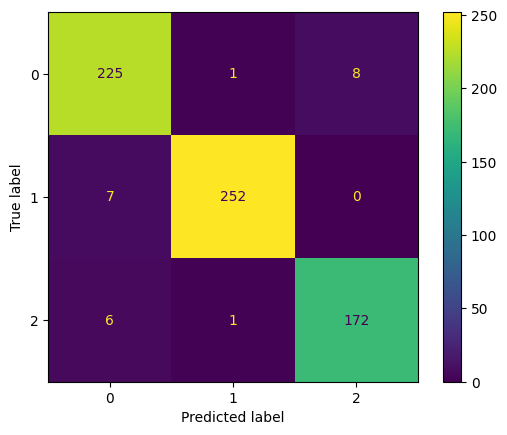

In [16]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

- **Reports**
**We can see that the model performed very well.**
- We used XGBoost as it gave the best accuracy-to-interpretability trade-off among the top-scoring models (CatBoost, XGBoost, Random Forest)
- We got strong accuracy while predicting on the held-out test dataset.